## General ##
This Jupyter notebook is for us to write code all at the same time. Please only write code in your given cells, indicated with the markdown.

## Writing code ##
We keep the unknown values for work on the weekends 
Compare per months for other categories, where you do have the data
Filters dataset: 2019 and 2023
(second dataset) Graph with colors of what cities are “stedelijk” and “niet stedelijk” → map of the Netherlands what is “stedelijk” and “niet stedelijk”
Dataset is in Dutch, but when plotting we can translate the axis’

Things to look at:
- Per year
- Urban vs rural
- Differences between school levels
- Whether week or weekend public transport (OV) or person cars matters

In [59]:
# import all the libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Code subquestion 1 ##

In [41]:
'''Reading the dataset: dataset1'''

df = pd.read_csv('Data/Dataset1.csv',\
    delimiter=';',\
    encoding='utf-8-sig',
    skiprows=4)    #skip the first 4 rows because they don't contain any needed data
df_copy = df.copy() #make a copy of the original dataframe
new_header = pd.MultiIndex.from_arrays(df.iloc[0:3].values) #make row with index 0,1 en 2 part of the column index. These rows don't contain any data and they should be part of the column index
df_copy.columns = new_header #make these rows part of the new column indexes
df1 = df_copy.iloc[3:,0:14] #show all rows and columns that are needed (from column 15 and on, it shows travel time instead of distance)
df1.head()

NaN               Regiokenmerken           Nederland  \
                     NaN                     Perioden                2019   
  Verplaatsingskenmerken                 Reismotieven reizigerskilometers   
3                Totaal                        Totaal               13,29   
4                Totaal          Van en naar het werk               19,26   
5                Totaal        Zakelijk, beroepsmatig               30,56   
6                Totaal   Winkelen, boodschappen doen                5,75   
7                Totaal               Visite, logeren               21,41   

                      Zeer sterk stedelijk                      \
                 2023                 2019                2023   
  reizigerskilometers  reizigerskilometers reizigerskilometers   
3               11,76                12,11               10,57   
4               18,33                17,26               16,35   
5               26,44                27,80               22,91   
6                5,23                 4,31                3,95   
7               19,34                24,55               22,16   

      Sterk stedelijk                         Matig stedelijk  \
                 2019                2023                2019   
  reizigerskilometers reizigerskilometers reizigerskilometers   
3               13,17               11,76               13,24   
4               19,30               18,84               19,99   
5               31,01               28,18               31,77   
6                5,32                5,02                6,46   
7               22,09               19,18               20,04   

                         Weinig stedelijk                      \
                 2023                2019                2023   
  reizigerskilometers reizigerskilometers reizigerskilometers   
3               11,80               13,89               12,45   
4               18,50               19,79               19,28   
5               28,57               31,28               26,07   
6                5,50                6,85                6,55   
7               18,39               18,89               17,28   

       Niet stedelijk                      
                 2019                2023  
  reizigerskilometers reizigerskilometers  
3               15,68               13,78  
4               22,01               19,46  
5               31,44               26,69  
6                7,90                6,74  
7               21,09               20,40

In [42]:
'''Filtering for missing or non-valid values
nothing : this number just doesn't exists based on logical facts
. : number is unknown, not reliable or secret
* : provisional number
** : additional provisional numberws if applicable'''

df1.isna().sum().sum()      #shows how many missing values (empty cells) there are, appears to be 13
(df1 == '.').sum().sum()    #shows how many cells include a '.' as value, appears to be 43
(df1 == '*').sum().sum()    #shows how many cells include a '*' as value, appears to be 0
(df1 == '**').sum().sum()   #shows how many cells include a '**' as value, appears to be 0
df1 = df1.replace('.', np.nan) #replacing all the '.' as a NaN
df1.isna().sum().sum()      #counting all the NaN's: total of 56 (so indeed the sum of the 13 real NaN and the 43 '.')

np.int64(56)

In [43]:
'''Formatting columnames from multiindex, to single index'''

new_cols = []                               #creating new list for new column names
for i, col in enumerate(df1.columns):       #looping through all columns
    if i == 0:                              #first column: (NaN, NaN, 'Verplaatsingskenmerken')
        new_cols.append('Day_of_movement')  #give this multindex column the name 'Day_of_movement'
    elif i == 1:                            #second column: ('Regiokenmerken', 'Perioden', 'Reismotieven')
        new_cols.append('Travel_motives')   #give this multindex column the name 'Travel_motives'
    else:                                   #all other columns containing the 'real' data
        new_cols.append(f"{col[0]}_{col[1]}") #ignoring the 3 item in each tuple: 'reizigerskilometers' because this item is the same everywhere so we can ignore it

df2 = df1.copy()                            #making a copy of the first dataframe
df2.columns = new_cols                      #giving this new dataframe the new single index column names
df2.head()

,Day_of_movement,Travel_motives,Nederland_2019,Nederland_2023,Zeer sterk stedelijk_2019,Zeer sterk stedelijk_2023,Sterk stedelijk_2019,Sterk stedelijk_2023,Matig stedelijk_2019,Matig stedelijk_2023,Weinig stedelijk_2019,Weinig stedelijk_2023,Niet stedelijk_2019,Niet stedelijk_2023
3,Totaal,Totaal,"13,29","11,76","12,11","10,57","13,17","11,76","13,24","11,80","13,89","12,45","15,68","13,78"
4,Totaal,Van en naar het werk,"19,26","18,33","17,26","16,35","19,30","18,84","19,99","18,50","19,79","19,28","22,01","19,46"
5,Totaal,"Zakelijk, beroepsmatig","30,56","26,44","27,80","22,91","31,01","28,18","31,77","28,57","31,28","26,07","31,44","26,69"
6,Totaal,"Winkelen, boodschappen doen","5,75","5,23","4,31","3,95","5,32","5,02","6,46","5,50","6,85","6,55","7,90","6,74"
7,Totaal,"Visite, logeren","21,41","19,34","24,55","22,16","22,09","19,18","20,04","18,39","18,89","17,28","21,09","20,40"


In [44]:
"""Melting dataframe from wide into long format"""
col_melt = [col for col in df2.columns if '0' in col]           #making a selection of all columns that contain a value (number). So all the columns which have a 0 in the name

df3 = df2[                                                      #creating a new dataframe which should contain...
    (df2['Travel_motives'] == 'Totaal') &                       #total travel motives instead of all seperate motives (work, school etc.)
    (df2['Day_of_movement'].str.contains('Verplaatsing op|Totaal'))].copy() #and the day of movement should be specified

#melting df3 to long format
df_long = pd.melt(
    df3,
    id_vars=['Day_of_movement', 'Travel_motives'],              #the columns we want to keep as they are
    value_vars=col_melt,                                        #the columns we want to melt (so all the columns that contain data)
    var_name='Regio_Jaar',                                      #name of the new column containing the specification
    value_name='Gemiddelde_Afstand_km'                          #name of new column containing the data per specification
)

#spliting the regio_jaar column
df_long[['Urbanity', 'Year']] = df_long['Regio_Jaar'].str.split('_', expand=True)
#adding an extra column 'Day' in which the day names are expressed shorter (which is better for visualisation later on)
df_long['Day'] = df_long['Day_of_movement'].str.replace('Verplaatsing op ', '', regex=False).str.capitalize()

#converting all ',' to '.' so graphing is possible later on
df_long['Gemiddelde_Afstand_km'] = (
    df_long['Gemiddelde_Afstand_km']
      .astype(str)                                              #making a string of the data so that we are able to perform string operations on it (such as replace ',' by '.')
      .str.replace('\u00A0', '')                                #delete non-breaking space 
      .str.replace(',', '.', regex=False))                      #replace ',' with '.' so python sees the data as floats

#convert all data to numeric so python sees the data as actual numbers and can make a graph with it later on
df_long['Gemiddelde_Afstand_km'] = pd.to_numeric(df_long['Gemiddelde_Afstand_km'], errors='coerce')

df_long.head(20)

,Day_of_movement,Travel_motives,Regio_Jaar,Gemiddelde_Afstand_km,Urbanity,Year,Day
0,Totaal,Totaal,Nederland_2019,13.29,Nederland,2019,Totaal
1,Verplaatsing op zondag,Totaal,Nederland_2019,18.33,Nederland,2019,Zondag
2,Verplaatsing op maandag,Totaal,Nederland_2019,12.41,Nederland,2019,Maandag
3,Verplaatsing op dinsdag,Totaal,Nederland_2019,13.12,Nederland,2019,Dinsdag
4,Verplaatsing op woensdag,Totaal,Nederland_2019,12.23,Nederland,2019,Woensdag
5,Verplaatsing op donderdag,Totaal,Nederland_2019,12.96,Nederland,2019,Donderdag
6,Verplaatsing op vrijdag,Totaal,Nederland_2019,12.46,Nederland,2019,Vrijdag
7,Verplaatsing op zaterdag,Totaal,Nederland_2019,13.12,Nederland,2019,Zaterdag
8,Totaal,Totaal,Nederland_2023,11.76,Nederland,2023,Totaal
9,Verplaatsing op zondag,Totaal,Nederland_2023,14.52,Nederland,2023,Zondag


In [45]:
"""Filtering the data to make usefull graphs"""

df_long['Day'] = df_long['Day'].astype(str).str.strip()         #remove all white spaces from the strings in column 'Day'
df_long = df_long[df_long['Day'] != 'Totaal']                   #show data for all days except for the 'totaal'



day_order = ['Maandag','Dinsdag','Woensdag','Donderdag','Vrijdag','Zaterdag','Zondag',] #making a list which shows the days in logical order
df_long['Day'] = pd.Categorical(df_long['Day'], categories=day_order, ordered=True)     #sorting the days according to the logical order

#converting the days to english
day_translation = {
    'Maandag': 'Monday',
    'Dinsdag': 'Tuesday',
    'Woensdag': 'Wednesday',
    'Donderdag': 'Thursday',
    'Vrijdag': 'Friday',
    'Zaterdag': 'Saturday',
    'Zondag': 'Sunday',
    'Totaal': 'Total'
}
df_long['Day'] = df_long['Day'].replace(day_translation)

#converting the level of urbanity to english
sted_translation = {
    'Nederland': 'Netherlands',
    'Zeer sterk stedelijk': 'Very strongly urban',
    'Sterk stedelijk': 'Strongly urban',
    'Matig stedelijk': 'Moderately urban',
    'Weinig stedelijk': 'Slightly urban',
    'Niet stedelijk': 'Not urban'
}

df_long['Urbanity'] = df_long['Urbanity'].replace(sted_translation)

df_long1 = df_long.copy()
df_long1 = df_long1[df_long1['Urbanity'] != 'Netherlands']           #show data for levels of urbanity except for the 'totaal' (so for whole Netherlands)

df_long1.head()

C:\Users\31628\AppData\Local\Temp\ipykernel_28088\3925394008.py:22: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_long['Day'] = df_long['Day'].replace(day_translation)


,Day_of_movement,Travel_motives,Regio_Jaar,Gemiddelde_Afstand_km,Urbanity,Year,Day
17,Verplaatsing op zondag,Totaal,Zeer sterk stedelijk_2019,17.31,Very strongly urban,2019,Sunday
18,Verplaatsing op maandag,Totaal,Zeer sterk stedelijk_2019,10.97,Very strongly urban,2019,Monday
19,Verplaatsing op dinsdag,Totaal,Zeer sterk stedelijk_2019,11.30,Very strongly urban,2019,Tuesday
20,Verplaatsing op woensdag,Totaal,Zeer sterk stedelijk_2019,11.74,Very strongly urban,2019,Wednesday
21,Verplaatsing op donderdag,Totaal,Zeer sterk stedelijk_2019,11.47,Very strongly urban,2019,Thursday


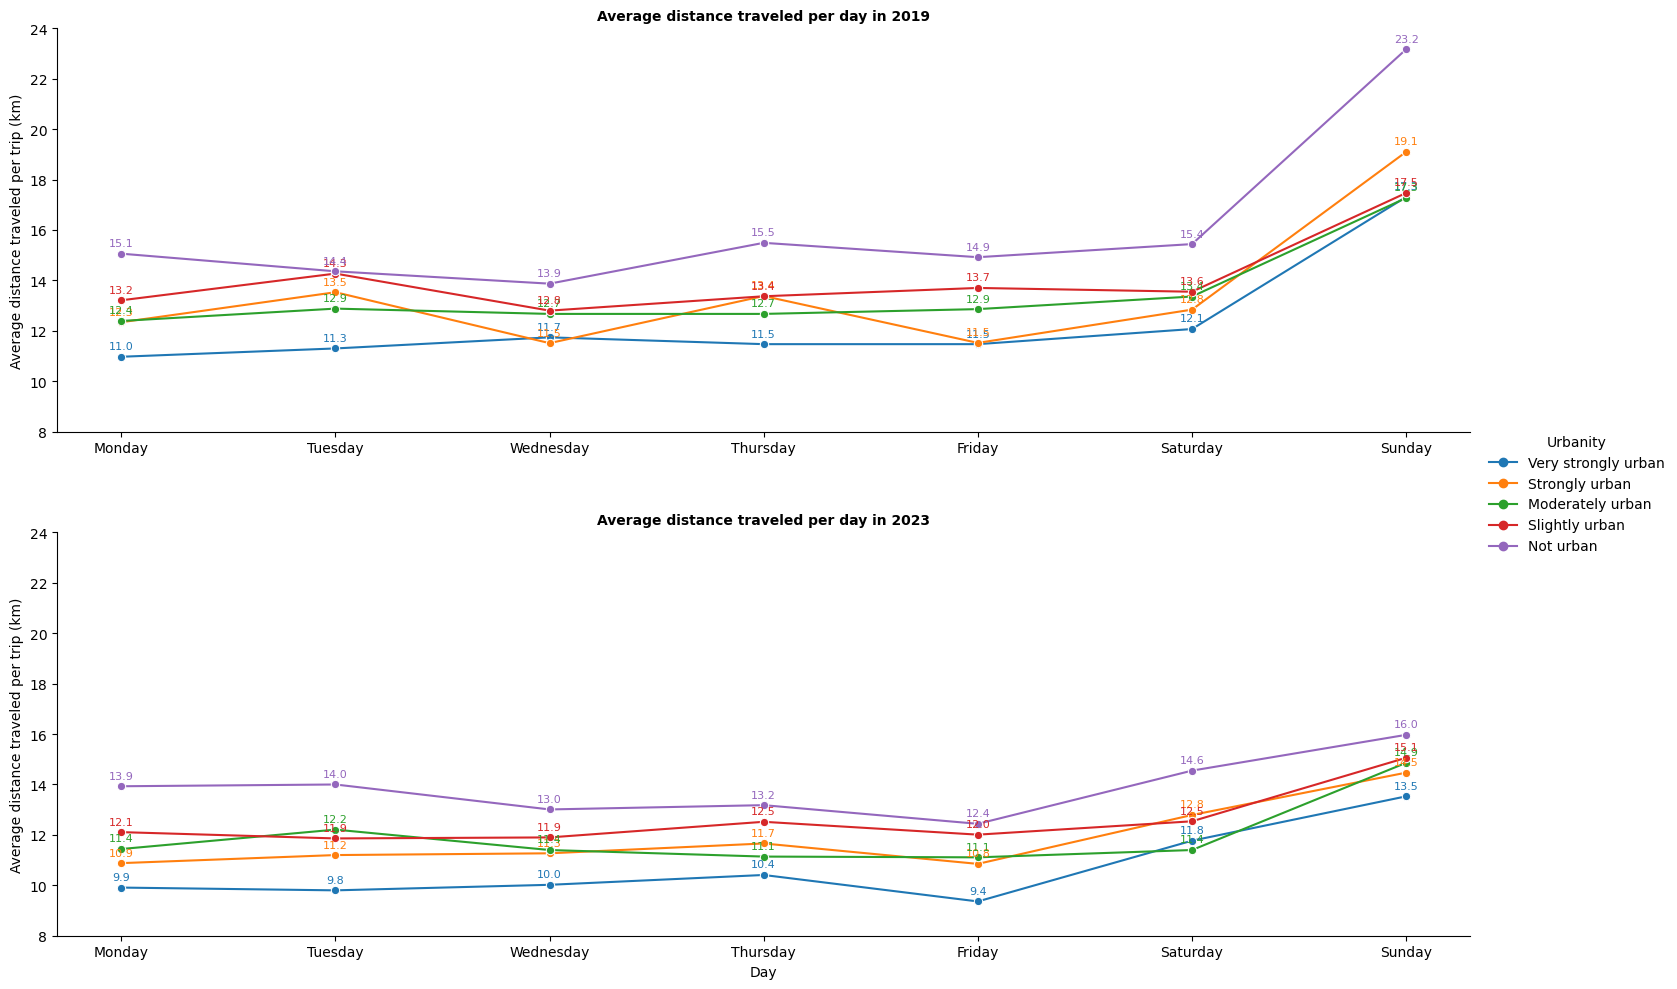

In [46]:
"""Making the graph for level of urbanity using seaborn"""
g = sns.relplot(
    data=df_long1,              #dataframe used
    x='Day',                    #Data shown on the x-axis is the days
    y='Gemiddelde_Afstand_km',  #Data shown on the y-axis is the distance travelled
    kind='line',                #Showing a line in the plot
    row='Year',                 #Make two rows in the plot: one for the year 2019, and one for the year 2023
    hue='Urbanity',             #Every amount of urbanity gets its own colour in both graphs
    marker='o',                 #Each datapoint is shown by a dot
    aspect=3.0,                 #Makes the graph broader and thus better readable
    height=5,                   #Determines the height of each graph
)

"""Adding lables for the axes and title"""
g.set_ylabels('Average distance traveled per trip (km)')    #y axis label
g.set(ylim=(8, 24))                                         #setting a minimum and maximum for the y axis 
g.fig.subplots_adjust(hspace=0.25)                          #add some more space between the two subplots 
g.set_titles("Average distance traveled per day in {row_name}",fontweight='bold') #title per subplot
for ax in g.axes.flat:                                      #loop through both subplots
    ax.tick_params(axis='x', labeltop=False, labelbottom=True) #adding x-lables on both subplots

    
"""Adding data labels"""
for ax in g.axes.flat:              #loop through both subplots
    for line in ax.lines:           #loop through al lines in subplot
        x_data = line.get_xdata()   #get the x data
        y_data = line.get_ydata()   #get the y data

        for x, y in zip(x_data, y_data):        #looping through x and y data
            ax.text(x, y + 0.3, f"{y:.1f}",     # 0.3 = placed above the data point
                    color=line.get_color(),
                    fontsize=8,
                    ha='center')
g.savefig("Figures/Graph_subq1.png", dpi=300, bbox_inches='tight')
plt.show()

In [47]:
"""Filtering the data to make the graph for the entire Netherlands"""

df_long_total = df_long.copy()
df_long['Day'] = df_long['Day'].astype(str).str.strip()                                         #remove all white spaces from the strings in column 'Day'
df_long_total = df_long_total[df_long_total['Day'].str.strip() != 'Totaal']                     #only show columns with total travel distance, and not the distance per day
df_long_total = df_long_total[df_long_total['Urbanity'].str.strip() == 'Netherlands']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday',]           #making a list which shows the days in logical order
df_long_total['Day'] = pd.Categorical(df_long_total['Day'], categories=day_order, ordered=True) #sorting the days according to the logical order
df_long_total = df_long_total.sort_values('Day')



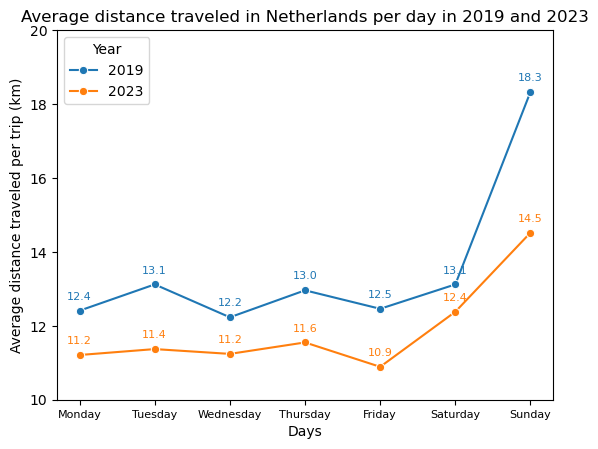

In [48]:
'''Making graph for Netherlands'''

fig, ax = plt.subplots()
sns.lineplot(
    data=df_long_total,
    x='Day',
    y='Gemiddelde_Afstand_km',
    hue='Year',
    marker='o',
    dashes=False,
    errorbar=None
)

#Adding lables for the axes and title
ax.set_ylabel('Average distance traveled per trip (km)') #y axis label
ax.set(ylim=(10, 20))                   #setting a minimum and maximum for the y axis 
ax.set_xlabel('Days')                   #x axis label
ax.tick_params(axis='x', labelsize=8)   #making the size from the day labels a bit smaller (otherwise they don't fit)
ax.set_title('Average distance traveled in Netherlands per day in 2019 and 2023')

#adding labels to the datapoints
for line in ax.lines:                 #looping throught both lines
    for x, y in zip(line.get_xdata(), line.get_ydata()): 
        ax.text(
            x, y + 0.3,               #placing the label 0.3 above the datapoint
            f"{y:.1f}",               #round the float to 1 decimal
            ha='center', fontsize=8,  #placing data label central and horizontally in fontsize 8
            color=line.get_color()    #use same colour for the label as the line it belongs to
        )

fig.savefig("Figures/Graph_subq1_total.png", dpi=300, bbox_inches='tight')
plt.show()

## Code subquestion 2 ##

In [49]:
"""Melting dataframe from wide into long format for subquestion 2"""
#creating a dataframe with leisure and work motives
df_sq2 = df2[                                                                                          
    (df2['Travel_motives'].isin(['Winkelen, boodschappen doen','Visite, logeren','Uitgaan, sport, hobby','Toeren, wandelen','Van en naar het werk', 'Zakelijk, beroepsmatig'])) & 
    (df2['Day_of_movement'].str.startswith('Verplaatsing op '))].copy() 

#melting df_sq2 to long format
df_sq2_long = pd.melt(
    df_sq2,
    id_vars=['Day_of_movement', 'Travel_motives'],              #the columns we want to keep as they are
    value_vars=col_melt,                                        #the columns we want to melt (so all the columns that contain data)
    var_name='Regio_Jaar',                                      #name of the new column containing the specification
    value_name='Gemiddelde_Afstand_km'                          #name of new column containing the data per specification
)

#spliting the regio_jaar column
df_sq2_long[['Urbanity', 'Year']] = df_sq2_long['Regio_Jaar'].str.split('_', expand=True)
#adding an extra column 'Day' in which the day names are expressed shorter (which is better for visualisation later on)
df_sq2_long['Day'] = df_sq2_long['Day_of_movement'].str.replace('Verplaatsing op ', '', regex=False).str.capitalize()

#converting all ',' to '.' so graphing is possible later on
df_sq2_long['Gemiddelde_Afstand_km'] = (
    df_sq2_long['Gemiddelde_Afstand_km']
      .astype(str)                                              #making a string of the data so that we are able to perform string operations on it (such as replace ',' by '.')
      .str.replace('\u00A0', '')                                #delete non-breaking space 
      .str.replace(',', '.', regex=False))                      #replace ',' with '.' so python sees the data as floats

#convert all data to numeric so python sees the data as actual numbers and can make a graph with it later on
df_sq2_long['Gemiddelde_Afstand_km'] = pd.to_numeric(df_sq2_long['Gemiddelde_Afstand_km'], errors='coerce')

df_sq2_long.tail(20)

,Day_of_movement,Travel_motives,Regio_Jaar,Gemiddelde_Afstand_km,Urbanity,Year,Day
484,Verplaatsing op woensdag,"Uitgaan, sport, hobby",Niet stedelijk_2023,10.68,Niet stedelijk,2023,Woensdag
485,Verplaatsing op woensdag,"Toeren, wandelen",Niet stedelijk_2023,6.97,Niet stedelijk,2023,Woensdag
486,Verplaatsing op donderdag,Van en naar het werk,Niet stedelijk_2023,20.70,Niet stedelijk,2023,Donderdag
487,Verplaatsing op donderdag,"Zakelijk, beroepsmatig",Niet stedelijk_2023,NaN,Niet stedelijk,2023,Donderdag
488,Verplaatsing op donderdag,"Winkelen, boodschappen doen",Niet stedelijk_2023,6.05,Niet stedelijk,2023,Donderdag
489,Verplaatsing op donderdag,"Visite, logeren",Niet stedelijk_2023,14.90,Niet stedelijk,2023,Donderdag
490,Verplaatsing op donderdag,"Uitgaan, sport, hobby",Niet stedelijk_2023,10.05,Niet stedelijk,2023,Donderdag
491,Verplaatsing op donderdag,"Toeren, wandelen",Niet stedelijk_2023,6.58,Niet stedelijk,2023,Donderdag
492,Verplaatsing op vrijdag,Van en naar het werk,Niet stedelijk_2023,15.79,Niet stedelijk,2023,Vrijdag
493,Verplaatsing op vrijdag,"Zakelijk, beroepsmatig",Niet stedelijk_2023,NaN,Niet stedelijk,2023,Vrijdag


In [50]:
"""Filtering the data to make useful graphs for leisure and work motives"""
df_sq2_long['Day'] = df_sq2_long['Day'].astype(str).str.strip() #remove all white spaces from the strings in column 'Day'
df_sq2_long = df_sq2_long[df_sq2_long['Day'] != 'Totaal']       #show data for all days except for the 'totaal'

df_sq2_long = df_sq2_long[df_sq2_long['Urbanity'] != 'Nederland'] 

#converting days to English
df_sq2_long['Day'] = df_sq2_long['Day'].replace(day_translation)

#day_order has been defined previously
df_sq2_long['Day'] = pd.Categorical(df_sq2_long['Day'], categories=day_order, ordered=True)

#translation of days has been defined previously
df_sq2_long['Day'] = df_sq2_long['Day'].replace(day_translation)

#translation of urbanity has been defined previously
df_sq2_long['Urbanity'] = df_sq2_long['Urbanity'].replace(sted_translation)

df_sq2_long.head()

,Day_of_movement,Travel_motives,Regio_Jaar,Gemiddelde_Afstand_km,Urbanity,Year,Day
84,Verplaatsing op zondag,Van en naar het werk,Zeer sterk stedelijk_2019,13.77,Very strongly urban,2019,Sunday
85,Verplaatsing op zondag,"Zakelijk, beroepsmatig",Zeer sterk stedelijk_2019,NaN,Very strongly urban,2019,Sunday
86,Verplaatsing op zondag,"Winkelen, boodschappen doen",Zeer sterk stedelijk_2019,4.70,Very strongly urban,2019,Sunday
87,Verplaatsing op zondag,"Visite, logeren",Zeer sterk stedelijk_2019,32.18,Very strongly urban,2019,Sunday
88,Verplaatsing op zondag,"Uitgaan, sport, hobby",Zeer sterk stedelijk_2019,17.35,Very strongly urban,2019,Sunday


C:\Users\31628\AppData\Local\Temp\ipykernel_28088\1486184216.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_leisure_2019.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()
C:\Users\31628\AppData\Local\Temp\ipykernel_28088\1486184216.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_work_2019.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()


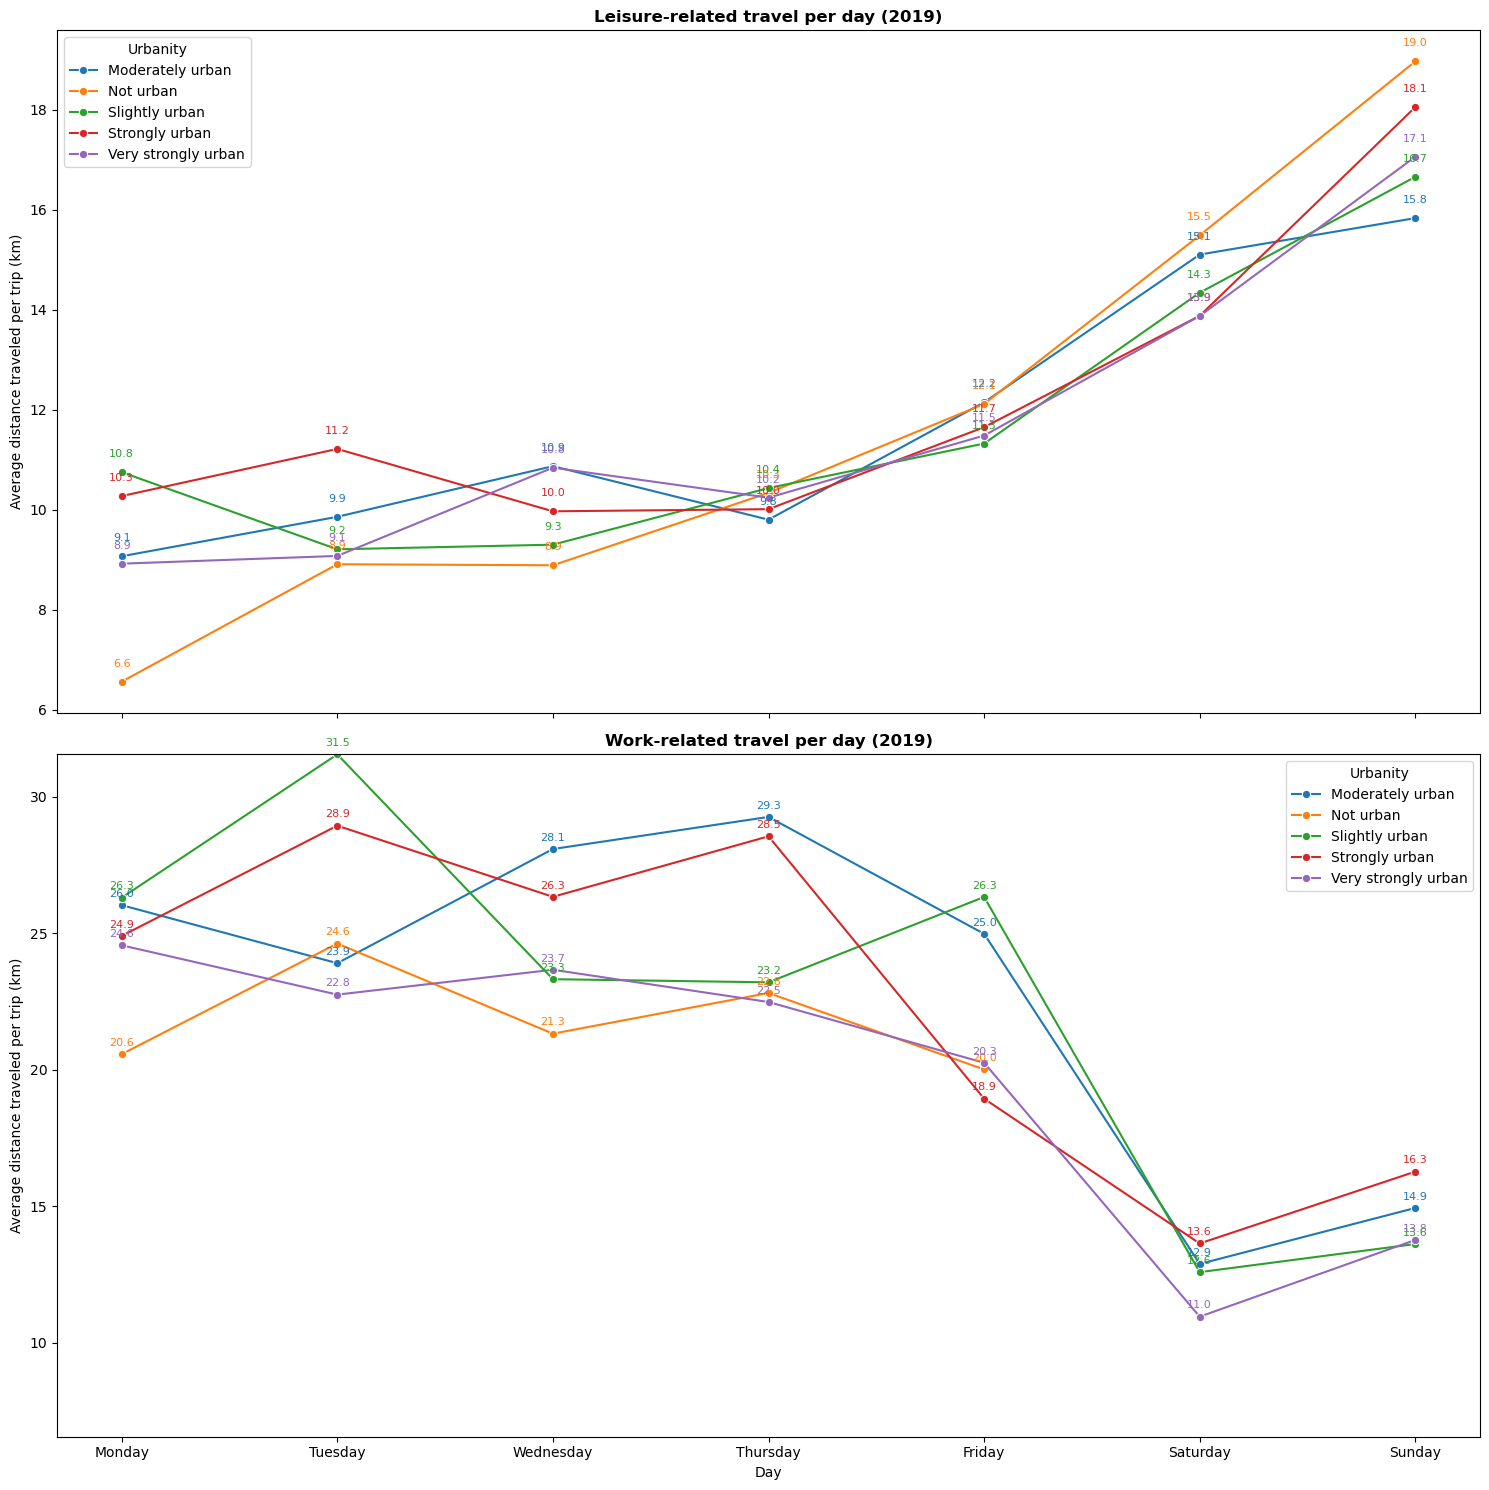

In [60]:
"""Making the subplots for work and leisure motives in 2019"""
#filter data from 2019 
df_2019 = df_sq2_long[df_sq2_long['Year'] == '2019'].copy()

#seperate leisure and work travel motives 
leisure = ['Winkelen, boodschappen doen', 'Visite, logeren', 'Uitgaan, sport, hobby', 'Toeren, wandelen']

work = ['Van en naar het werk', 'Zakelijk, beroepsmatig']

df_leisure_2019 = df_2019[df_2019['Travel_motives'].isin(leisure)]
df_work_2019 = df_2019[df_2019['Travel_motives'].isin(work)]

#day, level of urbanization and average distance
df_leisure_2019 = (
    df_leisure_2019.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()
)

df_work_2019 = (
    df_work_2019.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()
)

#days in order of the week
df_leisure_2019['Day'] = pd.Categorical(df_leisure_2019['Day'], categories=day_order, ordered=True)
df_work_2019['Day'] = pd.Categorical(df_work_2019['Day'], categories=day_order, ordered=True)

#deleting rows with non values
df_leisure_2019 = df_leisure_2019.dropna(subset=['Day'])
df_work_2019 = df_work_2019.dropna(subset=['Day'])

df_leisure_2019 = df_leisure_2019.sort_values(['Day'])
df_work_2019 = df_work_2019.sort_values(['Day'])

#determine y limits of both dataframes for equal plots
miny = min(df_leisure_2019['Gemiddelde_Afstand_km'].min(),
            df_work_2019['Gemiddelde_Afstand_km'].min()
)
maxy = max(df_leisure_2019['Gemiddelde_Afstand_km'].max(),
            df_work_2019['Gemiddelde_Afstand_km'].max()
)

#making figures for subplots
fig, axes = plt.subplots(2, 1, figsize=(15,15), sharex=True)

#leisure 2019 plot
sns.lineplot(
    data=df_leisure_2019,
    x='Day',
    y='Gemiddelde_Afstand_km',
    hue='Urbanity',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Leisure-related travel per day (2019)', fontweight='bold')
axes[0].set_ylabel('Average distance traveled per trip (km)')

#work 2019 plot
sns.lineplot(
    data=df_work_2019,
    x='Day',
    y='Gemiddelde_Afstand_km',
    hue='Urbanity',
    marker='o',
    ax=axes[1]
)
axes[1].set_title('Work-related travel per day (2019)', fontweight='bold')
axes[1].set_ylabel('Average distance traveled per trip (km)') 
axes[1].set_xlabel('Day')
axes[1].set_ylim(miny, maxy)

#adding datapoints
for ax in axes:
    for line in ax.lines:
        x_data = line.get_xdata()
        y_data = line.get_ydata()
        for x, y in zip(x_data, y_data):
            ax.text(x, y + 0.3, f"{y:.1f}", color=line.get_color(), fontsize=8, ha='center')

plt.tight_layout()
fig.savefig("Figures/Graph_subq2_2019.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\31628\AppData\Local\Temp\ipykernel_28088\4022895003.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_leisure_2023.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()
C:\Users\31628\AppData\Local\Temp\ipykernel_28088\4022895003.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_work_2023.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()


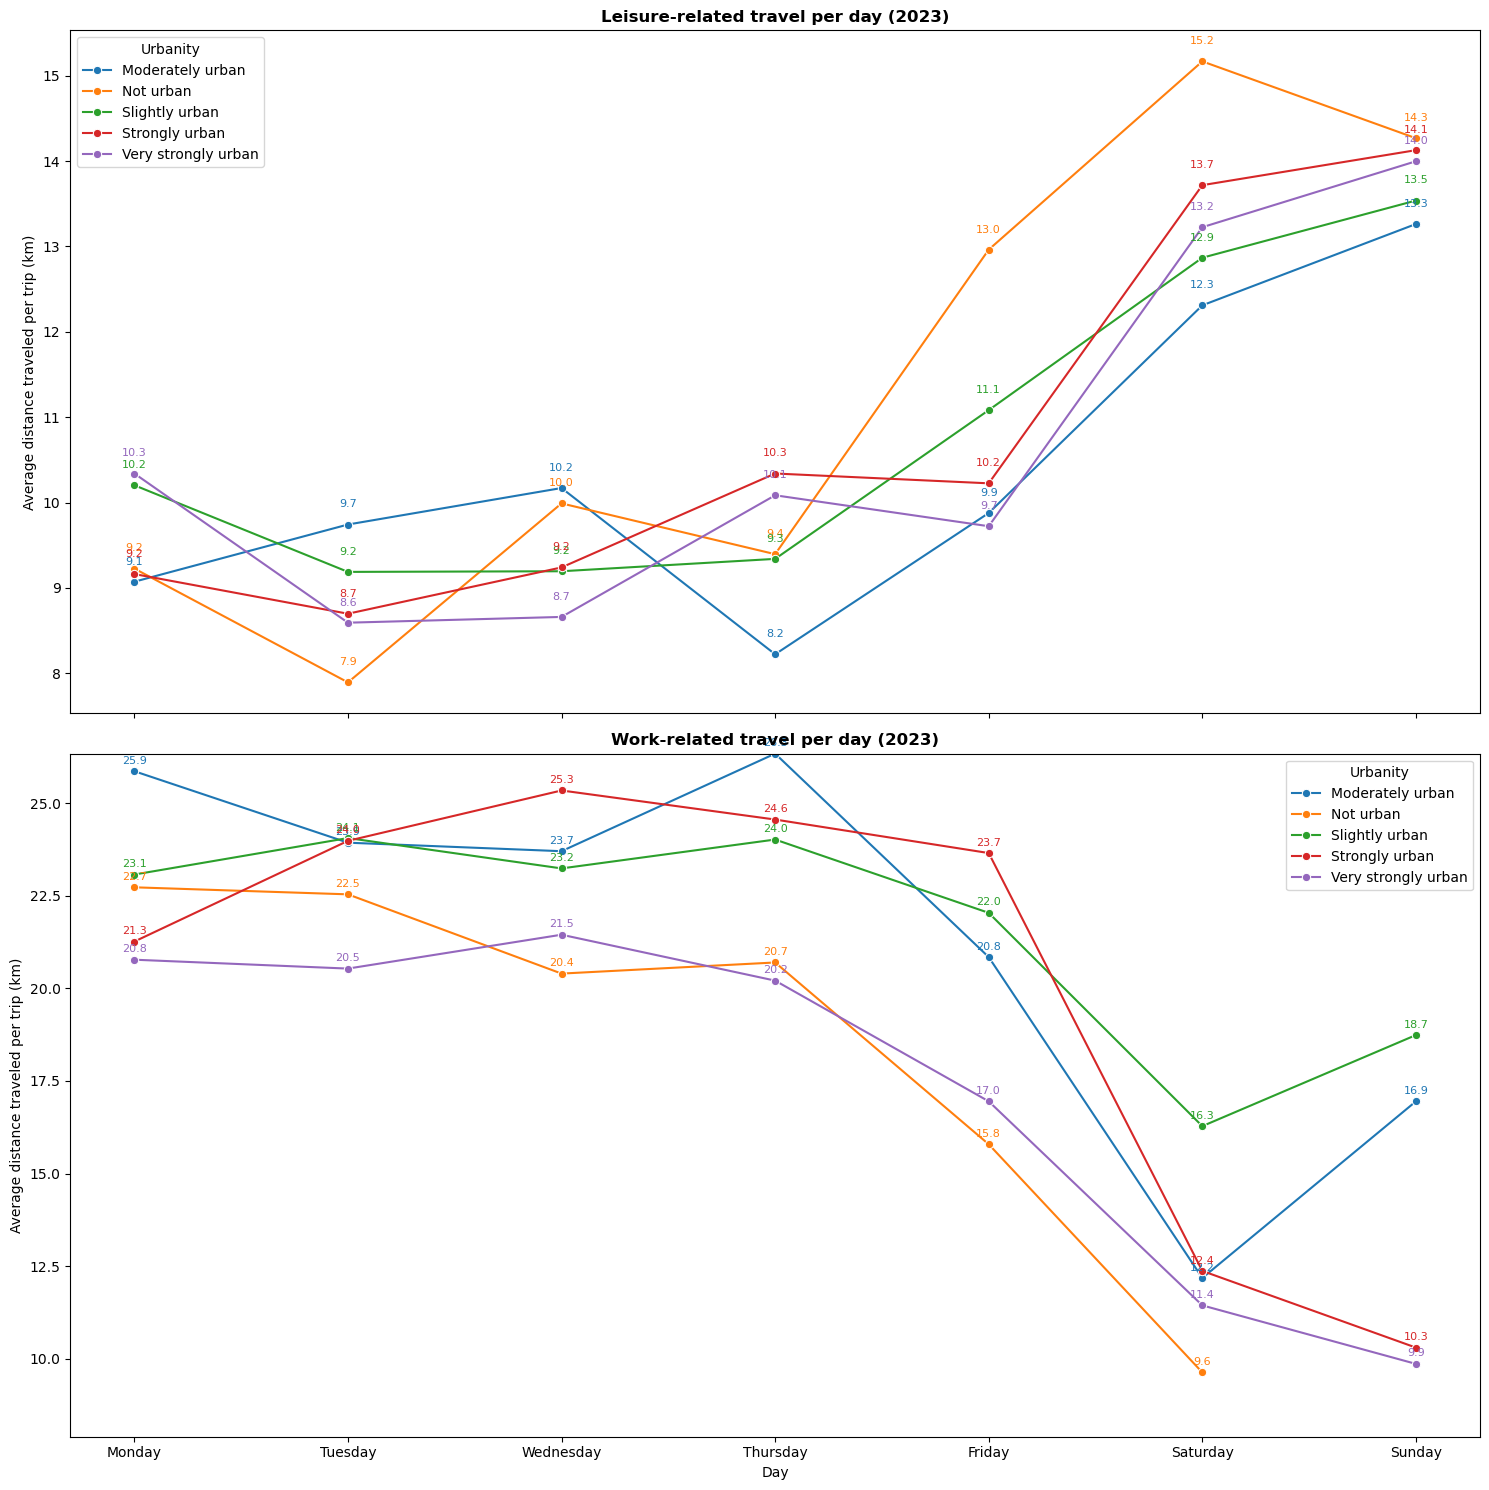

In [65]:
"""Making the subplots for work and leisure motives in 2023"""

#filter data from 2023 
df_2023 = df_sq2_long[df_sq2_long['Year'] == '2023'].copy()

#do the same for 2023 as for 2019

df_leisure_2023 = df_2023[df_2023['Travel_motives'].isin(leisure)]
df_work_2023 = df_2023[df_2023['Travel_motives'].isin(work)]

#day, level of urbanization and average distance
df_leisure_2023 = (
    df_leisure_2023.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()
)

df_work_2023 = (
    df_work_2023.groupby(['Day','Urbanity'], as_index=False)['Gemiddelde_Afstand_km'].mean()
)

#days in order of the week
df_leisure_2023['Day'] = pd.Categorical(df_leisure_2023['Day'], categories=day_order, ordered=True)
df_work_2023['Day'] = pd.Categorical(df_work_2023['Day'], categories=day_order, ordered=True)

df_leisure_2023 = df_leisure_2023.dropna(subset=['Day'])
df_work_2023 = df_work_2023.dropna(subset=['Day'])

df_leisure_2023 = df_leisure_2023.sort_values(['Day'])
df_work_2023 = df_work_2023.sort_values(['Day'])

#determine y limits of both dataframes
miny1 = min(df_leisure_2023['Gemiddelde_Afstand_km'].min(),
            df_work_2023['Gemiddelde_Afstand_km'].min()
)
maxy1 = max(df_leisure_2023['Gemiddelde_Afstand_km'].max(),
            df_work_2023['Gemiddelde_Afstand_km'].max()
)

#making figures for subplots
fig1, axes1 = plt.subplots(2, 1, figsize=(15,15), sharex=True)

#leisure 2023 plot
sns.lineplot(
    data=df_leisure_2023,
    x='Day',
    y='Gemiddelde_Afstand_km',
    hue='Urbanity',
    marker='o',
    ax=axes1[0]
)
axes1[0].set_title('Leisure-related travel per day (2023)', fontweight='bold')
axes1[0].set_ylabel('Average distance traveled per trip (km)')

#work 2023 plot
sns.lineplot(
    data=df_work_2023,
    x='Day',
    y='Gemiddelde_Afstand_km',
    hue='Urbanity',
    marker='o',
    ax=axes1[1]
)
axes1[1].set_title('Work-related travel per day (2023)', fontweight='bold')
axes1[1].set_ylabel('Average distance traveled per trip (km)') 
axes1[1].set_xlabel('Day')
axes1[1].set_ylim(miny1, maxy1)

#adding datapoints
for ax in axes1:
    for line in ax.lines:
        x_data = line.get_xdata()
        y_data = line.get_ydata()
        for x, y in zip(x_data, y_data):
            ax.text(x, y + 0.2, f"{y:.1f}", color=line.get_color(), fontsize=8, ha='center')


plt.tight_layout()
fig1.savefig("Figures/Graph_subq2_2023.png", dpi=300, bbox_inches='tight')
plt.show()

## Code subquestion 3 ##

In [53]:
'''Reading the dataset: dataset2'''

df_og = pd.read_csv('Data/Dataset2.csv', 
                    delimiter= ';',
                    header= [1, 2, 3, 4, 5],
                    skiprows= 4, # skip the first 4 rows because they don't contain any needed data
                    encoding='utf-8-sig'
                    ) 

df2 = df_og.copy()          # make a copy

df2.columns = ['_'.join([str(c) for c in col if str(c) != 'nan']).strip('_') for col in df2.columns] # makes one row of the index 

df2.head(20)

,Persoonskenmerken_Onderwerp_Regio's_Perioden_Reismotieven,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Weinig stedelijk_2019_aantal,...,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2023_reizigerskilometers
0,Totaal,"2,79","2,68","2,65","2,51","2,76","2,71","2,89","2,74","2,95",...,"23,95","20,01","23,94","23,49","24,72","23,99","29,39","26,65","30,81","31,16"
1,Van en naar het werk,"0,15","0,14","0,15","0,12","0,14","0,14","0,13","0,13","0,18",...,"1,43","0,81","1,60","1,36","1,20","0,81","1,49","1,32",.,.
2,"Winkelen, boodschappen doen","0,29","0,32","0,35","0,39","0,28","0,32","0,29","0,30","0,24",...,"1,28","1,51","1,17","1,56","2,35","1,80","2,02","2,44","2,91",.
3,"Onderwijs volgen, cursus, kinderopvang","0,98","0,85","0,91","0,75","0,97","0,90","1,06","0,90","1,05",...,"6,23","4,34","6,93","6,49","8,06","6,65","8,69","7,40","9,84","8,74"
4,"Visite, logeren","0,29","0,29","0,25","0,24","0,31","0,29","0,29","0,30","0,32",...,"5,30","4,49","4,83","4,26","3,97","4,47","4,47","4,03","3,72","4,70"
5,"Uitgaan, sport, hobby","0,78","0,74","0,70","0,68","0,77","0,73","0,80","0,78","0,89",...,"6,36","5,77","6,26","7,16","6,06","7,09","9,63","8,61","7,99","10,00"
6,Bron: CBS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
'''Filtering for missing or non-valid values
nothing : this number just doesn't exists based on logical facts
. : number is unknown, not reliable or secret
* : provisional number
** : additional provisional numberws if applicable'''

print("Empty cels:", df2.isna().sum().sum())            # count empty cells 
print("Cels with '.':", (df2 == '.').sum().sum())       # count . 
print("Cels with '*':", (df2 == '*').sum().sum())       # count *
print("Cels with '**':", (df2 == '**').sum().sum())     # count **
df2 = df2.replace({'.': 0, '*': np.nan, '**': np.nan})  # replacing all the '.' as a NaN
print("Empty cels:", df2.isna().sum().sum())            # check is replacing is done

'''Changing numeric colums to real values'''

df2 = df2.applymap(lambda x: pd.to_numeric(str(x).replace(',', '.'), errors='ignore'))          # replaces strings to numbers 
df2 = df2[df2['Persoonskenmerken_Onderwerp_Regio\'s_Perioden_Reismotieven'] != 'Bron: CBS']     # delet last row

df2.head(12)                                            # shows the new table 

Empty cels: 24
Cels with '.': 3
Cels with '*': 0
Cels with '**': 0
Empty cels: 24


C:\Users\31628\AppData\Local\Temp\ipykernel_28088\1188896466.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df2 = df2.applymap(lambda x: pd.to_numeric(str(x).replace(',', '.'), errors='ignore'))          # replaces strings to numbers
C:\Users\31628\AppData\Local\Temp\ipykernel_28088\1188896466.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df2 = df2.applymap(lambda x: pd.to_numeric(str(x).replace(',', '.'), errors='ignore'))          # replaces strings to numbers


,Persoonskenmerken_Onderwerp_Regio's_Perioden_Reismotieven,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Nederland_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Zeer sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Sterk stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2019_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Matig stedelijk_2023_aantal,Participatie:student/scholier_Gemiddeld per persoon per dag |Verplaatsingen _Weinig stedelijk_2019_aantal,...,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Zeer sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Sterk stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Matig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Weinig stedelijk_2023_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2019_reizigerskilometers,Participatie:student/scholier_Gemiddeld per persoon per dag |Afstand _Niet stedelijk_2023_reizigerskilometers
0,Totaal,2.79,2.68,2.65,2.51,2.76,2.71,2.89,2.74,2.95,...,23.95,20.01,23.94,23.49,24.72,23.99,29.39,26.65,30.81,31.16
1,Van en naar het werk,0.15,0.14,0.15,0.12,0.14,0.14,0.13,0.13,0.18,...,1.43,0.81,1.6,1.36,1.2,0.81,1.49,1.32,0,0
2,Winkelen. boodschappen doen,0.29,0.32,0.35,0.39,0.28,0.32,0.29,0.3,0.24,...,1.28,1.51,1.17,1.56,2.35,1.8,2.02,2.44,2.91,0
3,Onderwijs volgen. cursus. kinderopvang,0.98,0.85,0.91,0.75,0.97,0.9,1.06,0.9,1.05,...,6.23,4.34,6.93,6.49,8.06,6.65,8.69,7.4,9.84,8.74
4,Visite. logeren,0.29,0.29,0.25,0.24,0.31,0.29,0.29,0.3,0.32,...,5.3,4.49,4.83,4.26,3.97,4.47,4.47,4.03,3.72,4.7
5,Uitgaan. sport. hobby,0.78,0.74,0.7,0.68,0.77,0.73,0.8,0.78,0.89,...,6.36,5.77,6.26,7.16,6.06,7.09,9.63,8.61,7.99,10.0


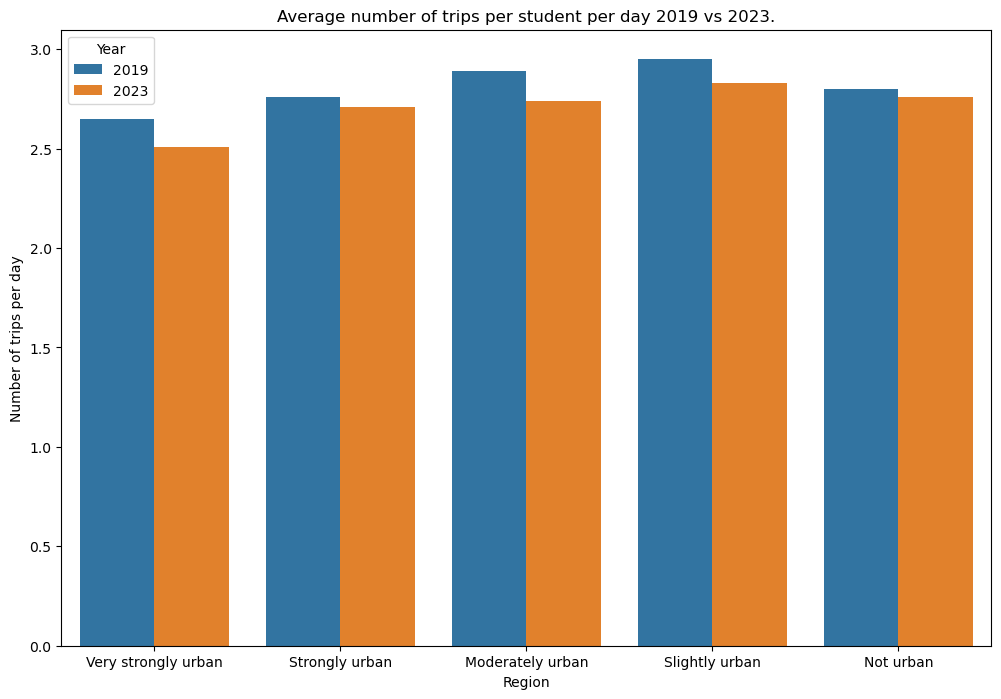

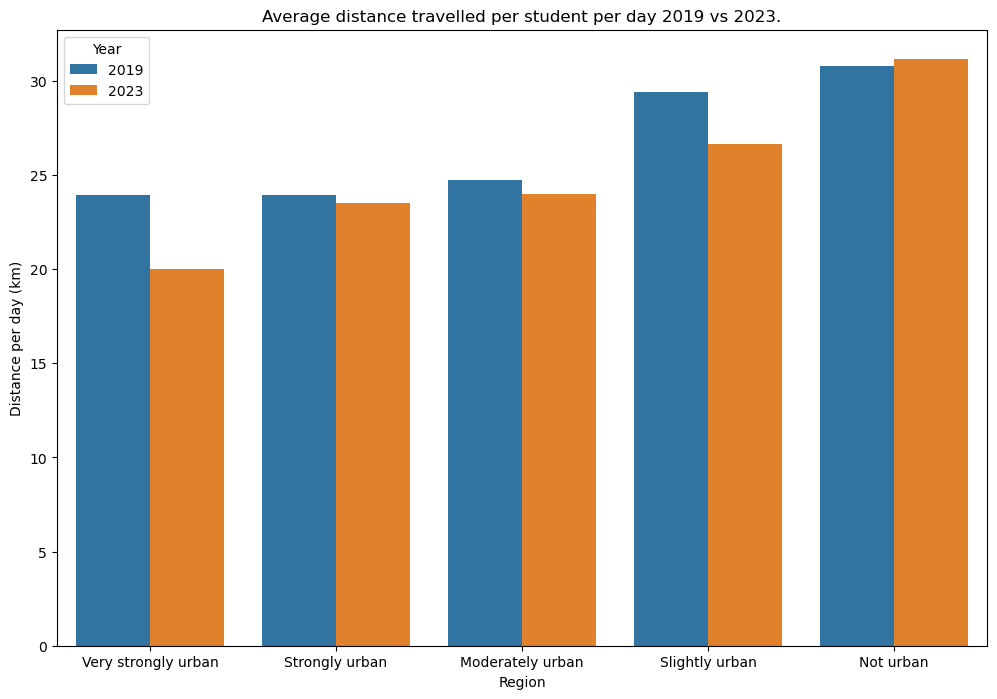

In [55]:
'''Make a barchart of the average trips and distance per region per year'''

# Filter the 'Totaal' row
df_totaal = df2[df2['Persoonskenmerken_Onderwerp_Regio\'s_Perioden_Reismotieven'] == 'Totaal']

# Regions and years
regio_list = ['Very strongly urban', 'Strongly urban', 'Moderately urban', 'Slightly urban', 'Not urban']
jaar_list = ['2019', '2023']

# Function to find column names that match by subject, region and year
def get_columns(df, onderwerp, jaren):
    cols = []
    regio_mapping = {
        'Very strongly urban': 'Zeer sterk stedelijk',
        'Strongly urban': 'Sterk stedelijk',
        'Moderately urban': 'Matig stedelijk',
        'Slightly urban': 'Weinig stedelijk',
        'Not urban': 'Niet stedelijk'
    }
    for regio_eng in regio_list:
        regio_nl = regio_mapping[regio_eng]
        for jaar in jaren:
            match = [c for c in df.columns if onderwerp in c and regio_nl in c and jaar in c]
            if match:
                cols.append(match[0])
    return cols

# Automatically select columns
cols_aantal = get_columns(df_totaal, 'Verplaatsingen', jaar_list)
cols_km = get_columns(df_totaal, 'Afstand', jaar_list)

# Create a long-form data frame for plotting
data_plot = pd.DataFrame({
    'Regio': [regio for regio in regio_list for _ in jaar_list],
    'Jaar': jaar_list*len(regio_list),
    'Aantal verplaatsingen': df_totaal[cols_aantal].values.flatten(),
    'Afstand (km)': df_totaal[cols_km].values.flatten()
})

# Plot number of movements
plt.figure(figsize=(12,8))
sns.barplot(x='Regio', y='Aantal verplaatsingen', hue='Jaar', data=data_plot)
plt.title('Average number of trips per student per day 2019 vs 2023.')
plt.ylabel('Number of trips per day')
plt.xlabel('Region')
plt.legend(title='Year')
plt.savefig("Figures/Barplot3.1.png", dpi=300, bbox_inches='tight')
plt.show()

# Plot distance 
plt.figure(figsize=(12,8))
sns.barplot(x='Regio', y='Afstand (km)', hue='Jaar', data=data_plot)
plt.title('Average distance travelled per student per day 2019 vs 2023.')
plt.ylabel('Distance per day (km)')
plt.xlabel('Region')
plt.legend(title='Year')
plt.savefig("Figures/Barplot3.2.png", dpi=300, bbox_inches='tight')
plt.show()

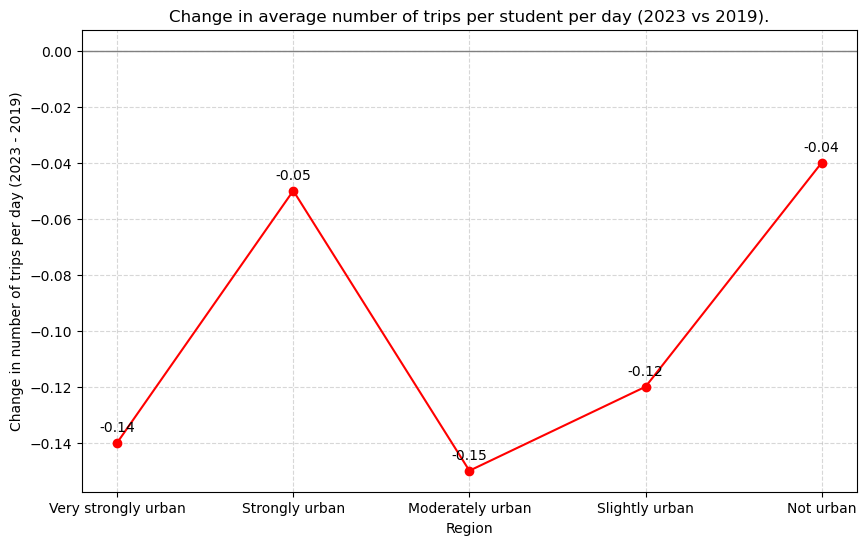

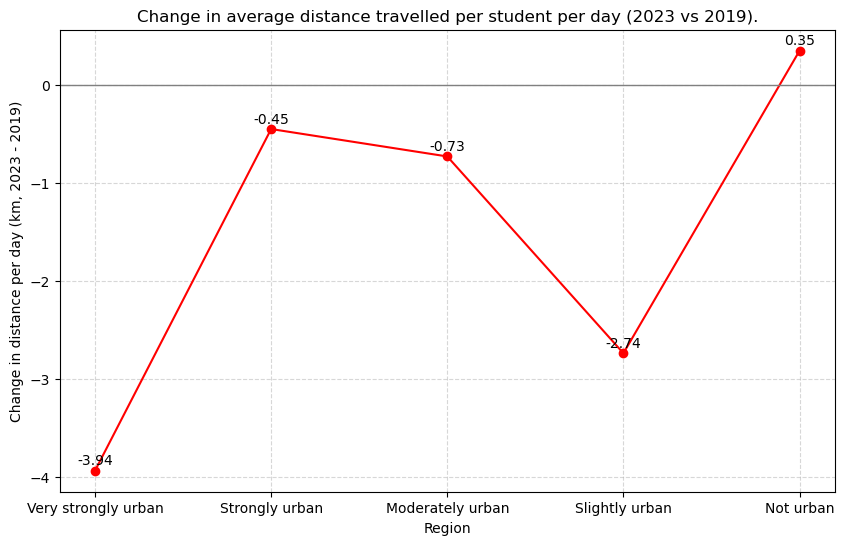

In [56]:
'''Make a line graph of the differance average trips and distance per region per year'''

# Region order
regio_order = ['Very strongly urban', 'Strongly urban', 'Moderately urban', 'Slightly urban', 'Not urban']

# Make pivot
pivot_aantal = data_plot.pivot(index='Regio', columns='Jaar', values='Aantal verplaatsingen')
pivot_afstand = data_plot.pivot(index='Regio', columns='Jaar', values='Afstand (km)')

# Set index as categorical to maintain order
pivot_aantal.index = pd.CategoricalIndex(pivot_aantal.index, categories=regio_order, ordered=True)
pivot_afstand.index = pd.CategoricalIndex(pivot_afstand.index, categories=regio_order, ordered=True)

# Sort according to the desired order
pivot_aantal = pivot_aantal.sort_index()
pivot_afstand = pivot_afstand.sort_index()

# Calculate difference (2023 - 2019)
pivot_aantal['Verschil'] = pivot_aantal['2023'] - pivot_aantal['2019'] 
pivot_afstand['Verschil'] = pivot_afstand['2023'] - pivot_afstand['2019']


# Make function for graphs 
def plot_change(pivot_df, title, ylabel, color, offset, save_path):
    plt.figure(figsize=(10,6))

    plt.plot(range(len(pivot_df.index)), pivot_df['Verschil'], linestyle='-', marker='o', color=color)
    for i, val in enumerate(pivot_df['Verschil']):
        plt.text(i, val + offset, f"{val:.2f}", ha='center', va='bottom', fontsize=10)


    plt.axhline(0, color='gray', linewidth=1)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Region')
    plt.xticks(range(len(pivot_df.index)), pivot_df.index)
    plt.grid(True, linestyle='--', alpha=0.5)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Plot graphs 
plot_change(pivot_aantal, 
            'Change in average number of trips per student per day (2023 vs 2019).',
            'Change in number of trips per day (2023 - 2019)',
            color='red', offset=0.003, save_path="Figures/LineGraph3.1.png")

plot_change(pivot_afstand, 
            'Change in average distance travelled per student per day (2023 vs 2019).',
            'Change in distance per day (km, 2023 - 2019)',
            color='red', offset=0.03, save_path="Figures/LineGraph3.2.png")

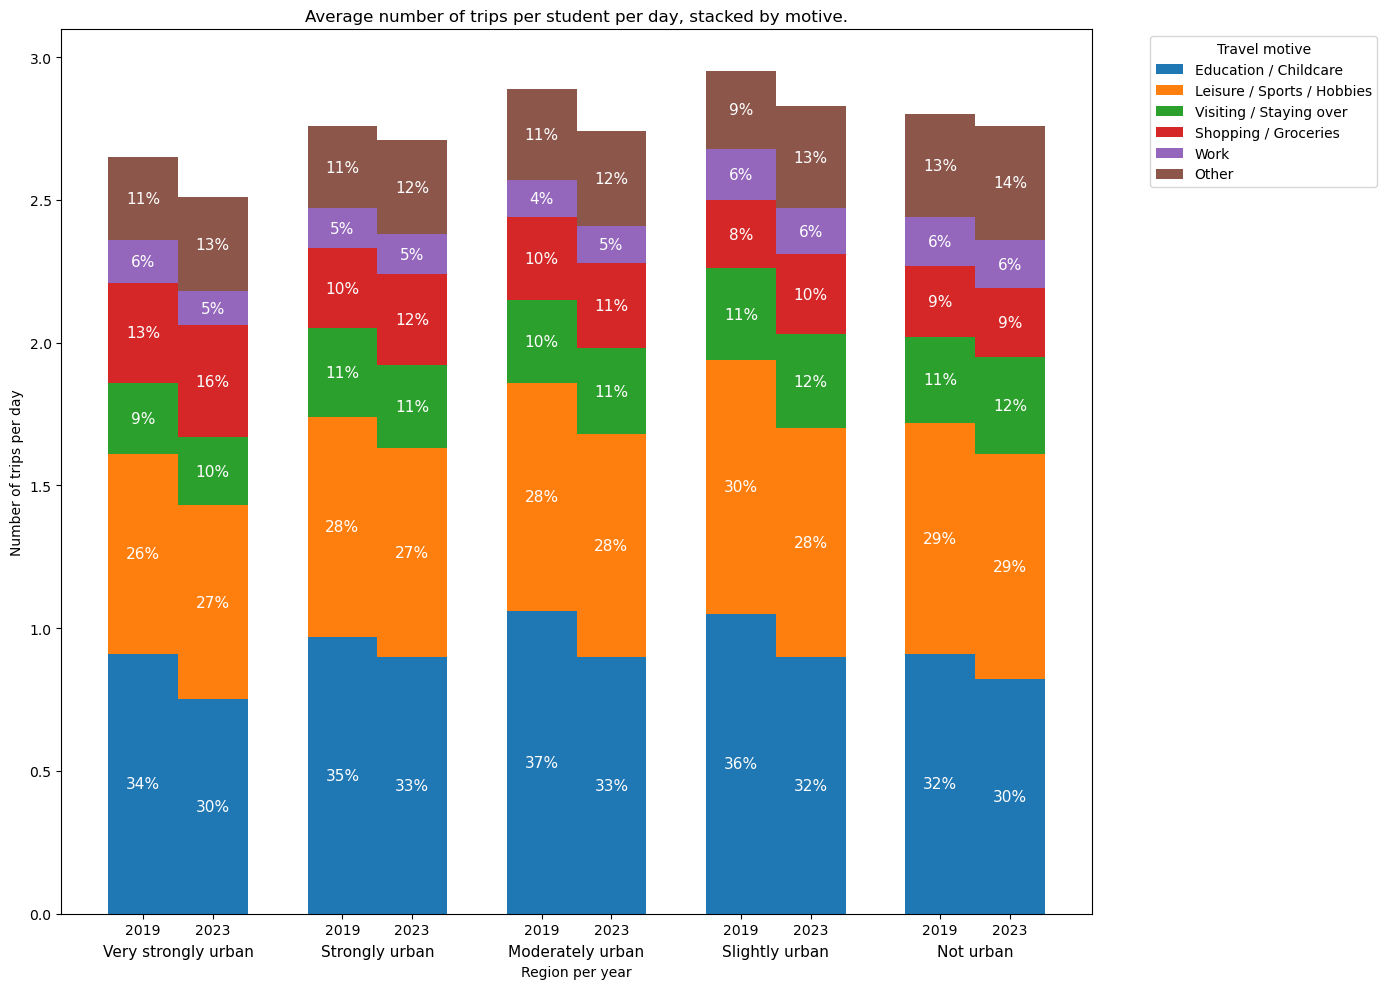

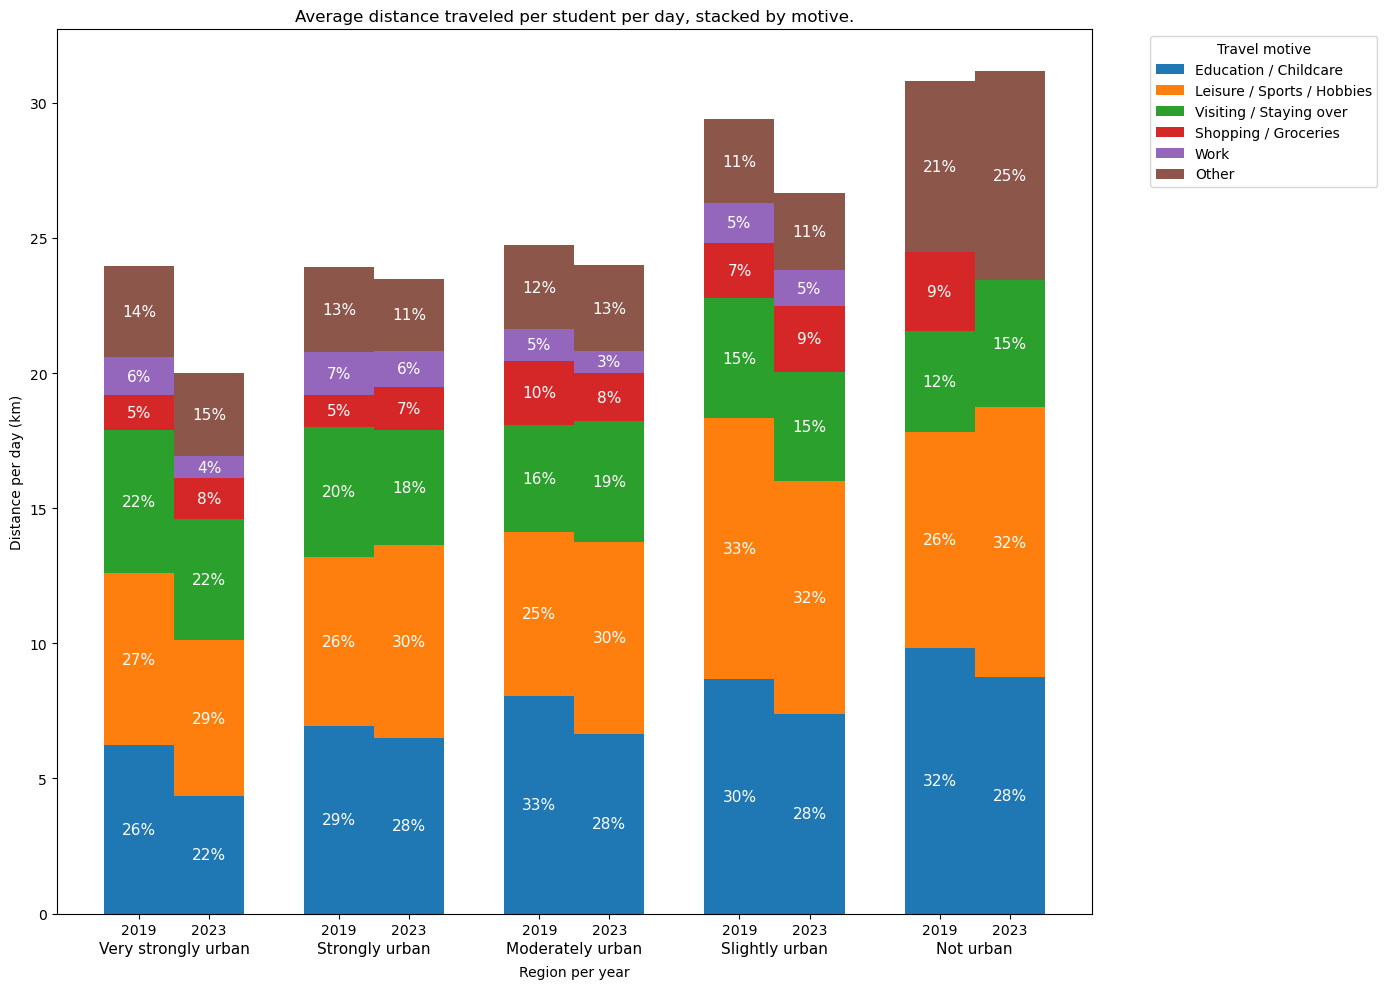

In [57]:
'''Make the same bar chart but with travle motives'''

# Region and year mapping 
regio_list = ['Very strongly urban', 'Strongly urban', 'Moderately urban', 'Slightly urban', 'Not urban']
jaar_list = ['2019', '2023']
regio_mapping = {
    'Very strongly urban': 'Zeer sterk stedelijk',
    'Strongly urban': 'Sterk stedelijk',
    'Moderately urban': 'Matig stedelijk',
    'Slightly urban': 'Weinig stedelijk',
    'Not urban': 'Niet stedelijk'
}

motieven_eng = {
        'Onderwijs volgen. cursus. kinderopvang': 'Education / Childcare',
        'Uitgaan. sport. hobby': 'Leisure / Sports / Hobbies',
        'Visite. logeren': 'Visiting / Staying over',
        'Winkelen. boodschappen doen': 'Shopping / Groceries',
        'Van en naar het werk': 'Work',
        'Overig': 'Other'
    }

def get_columns(df, onderwerp, jaren):
    cols = []
    for regio_eng in regio_list:
        regio_nl = regio_mapping[regio_eng]
        for jaar in jaren:
            match = [c for c in df.columns if onderwerp in c and regio_nl in c and jaar in c]
            if match:
                cols.append(match[0])
    return cols

cols_aantal = get_columns(df2, 'Verplaatsingen', jaar_list)
cols_km = get_columns(df2, 'Afstand', jaar_list)

# Prepare data 
motieven = df2['Persoonskenmerken_Onderwerp_Regio\'s_Perioden_Reismotieven'].tolist()
motieven.remove('Totaal')

plots = {}
for metric_name, cols in [('Aantal verplaatsingen', cols_aantal),
                          ('Afstand (km)', cols_km)]:
    data_list = []
    for i, regio_eng in enumerate(regio_list):
        for j, jaar in enumerate(jaar_list):
            col = cols[i*len(jaar_list) + j]
            totaal = df2.loc[df2['Persoonskenmerken_Onderwerp_Regio\'s_Perioden_Reismotieven'] == 'Totaal', col].values[0]
            motief_values = df2[df2['Persoonskenmerken_Onderwerp_Regio\'s_Perioden_Reismotieven'].isin(motieven)][col].values
            rest = totaal - np.nansum(motief_values)
            motief_values = np.append(motief_values, rest)
            motief_labels = motieven + ['Overig']
            for m, v in zip(motief_labels, motief_values):
                data_list.append([regio_eng, jaar, m, v])
    plots[metric_name] = pd.DataFrame(data_list, columns=['Regio', 'Jaar', 'Motief', 'Waarde'])

# Plot function
def plot_stacked(df, title, ylabel, save_path):
    plt.figure(figsize=(14, 10))
    colors = sns.color_palette('tab10', df['Motief'].nunique())

    bar_width = 0.35
    x_positions = []
    x_labels = []

    for i, (jaar, kleur_factor) in enumerate(zip(jaar_list, [0.8, 1.0])):
        subset = df[df['Jaar'] == jaar]
        bottom = np.zeros(len(regio_list))
        for idx, motief in enumerate(['Onderwijs volgen. cursus. kinderopvang', 
                                      'Uitgaan. sport. hobby',
                                      'Visite. logeren',
                                      'Winkelen. boodschappen doen',
                                      'Van en naar het werk',
                                      'Overig']):
            values = []
            for regio in regio_list:
                val = subset.loc[(subset['Regio'] == regio) & (subset['Motief'] == motief), 'Waarde']
                values.append(val.values[0] if len(val) else 0)
                
            eng_label = f"{motieven_eng.get(motief, motief)}" if i == 0 else None
            xpos = np.arange(len(regio_list)) + (i-0.5)*bar_width
            plt.bar(xpos, values, width=bar_width, label=eng_label, 
                    color=colors[idx % len(colors)], bottom=bottom)
            bottom += np.array(values)

        for x in xpos:
            x_positions.append(x)
            x_labels.append(jaar)

        # percentages in the bar
        for x, regio in enumerate(regio_list):
            total = subset[subset['Regio'] == regio]['Waarde'].sum()
            cum = 0
            for motief in ['Onderwijs volgen. cursus. kinderopvang', 
                           'Uitgaan. sport. hobby',
                           'Visite. logeren',
                           'Winkelen. boodschappen doen',
                           'Van en naar het werk',
                           'Overig']:
                val = subset.loc[(subset['Regio'] == regio) & (subset['Motief'] == motief), 'Waarde']
                if len(val) > 0 and total > 0:
                    pct = val.values[0] / total * 100
                    if pct > 0:  # Only plot higer than zero 
                        plt.text(x + (i-0.5)*0.35, cum + val.values[0]/2,
                                 f"{pct:.0f}%", ha='center', va='center', color='white', fontsize=11)
                    cum += val.values[0]

    plt.xticks(x_positions, x_labels)
    for i, regio in enumerate(regio_list):
        xpos_center = np.mean([np.arange(len(regio_list))[i] - 0.5*bar_width,
                               np.arange(len(regio_list))[i] + 0.5*bar_width])
        plt.text(i, -max(df['Waarde']) * 0.1, regio, ha='center', va='top', fontsize=11)


    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Region per year', labelpad= 20)
    plt.legend(title='Travel motive', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Plot both graphs
plot_stacked(plots['Aantal verplaatsingen'], 
             'Average number of trips per student per day, stacked by motive.', 
             'Number of trips per day', save_path="Figures/Barchart3.3.png")

plot_stacked(plots['Afstand (km)'], 
             'Average distance traveled per student per day, stacked by motive.', 
             'Distance per day (km)', save_path="Figures/Barchart3.4.png")


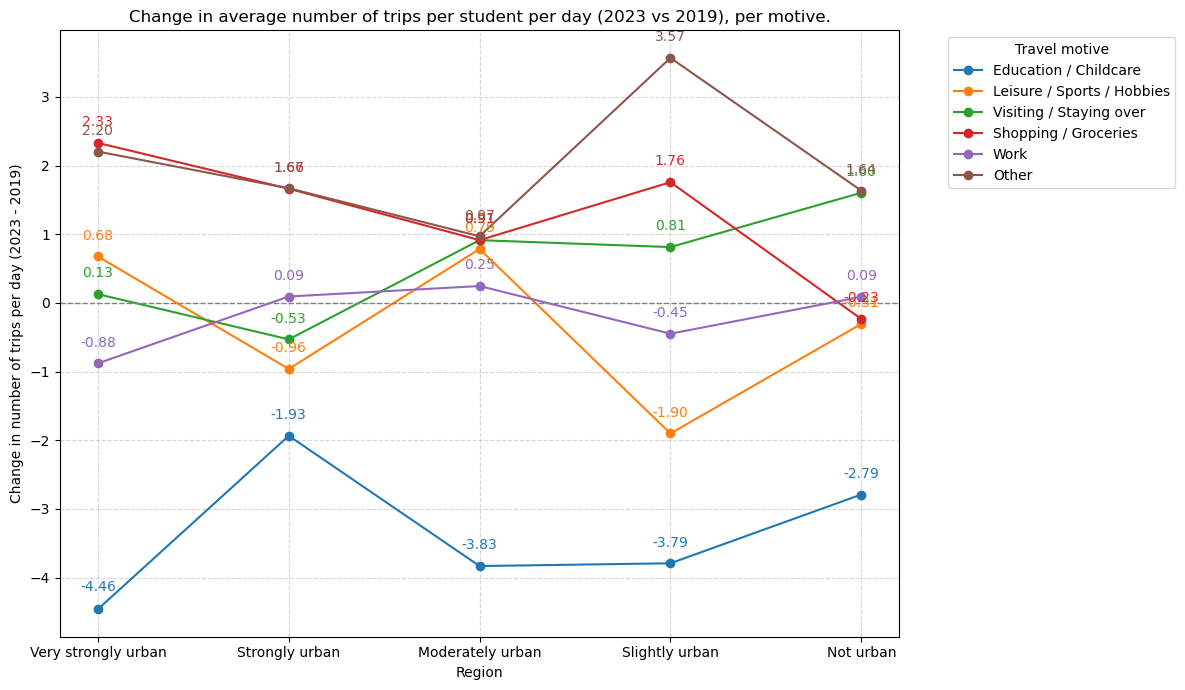

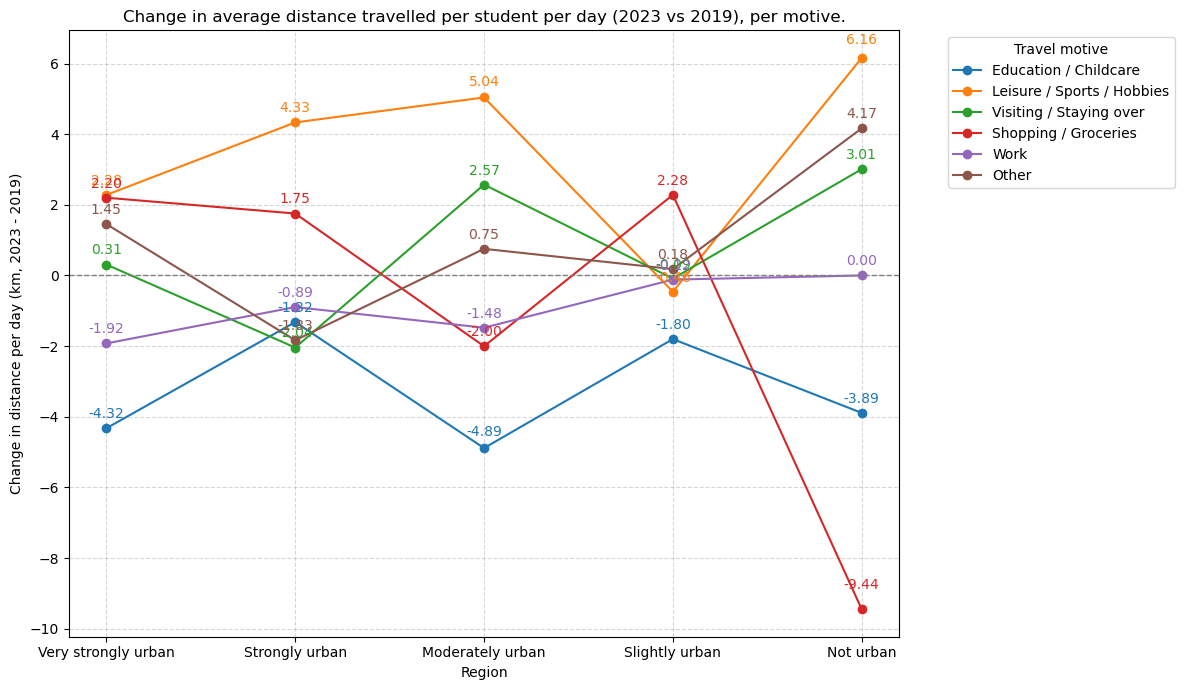

In [58]:
'''Make the same line graph of differance but with the 5 travle motives'''

regio_order = ['Very strongly urban', 'Strongly urban', 'Moderately urban', 'Slightly urban', 'Not urban']

def plot_motive_change(df, metric_col, title, ylabel, offset, save_path):
    """
    Line graph of percentage change (2023-2019) by motive, by region.
    df: DataFrame with columns ['Region', 'Year', 'Motive', metric_col]
    """
    plt.figure(figsize=(12,7))

    motieven = [
        'Onderwijs volgen. cursus. kinderopvang',
        'Uitgaan. sport. hobby',
        'Visite. logeren',
        'Winkelen. boodschappen doen',
        'Van en naar het werk',
        'Overig'
    ]

    colors = sns.color_palette('tab10', len(motieven))

    for color, motief in zip(colors, motieven):
        sub = df[df['Motief'] == motief].pivot(index='Regio', columns='Jaar', values=metric_col)

        # Put index in order
        sub.index = pd.CategoricalIndex(sub.index, categories=regio_order, ordered=True)
        sub = sub.sort_index()

        # Difference between 2023 and 2019 in percentage 
        totals = df.groupby(['Regio', 'Jaar'])[metric_col].sum().unstack()
        for jaar in ['2019', '2023']:
            sub[f'{jaar}_pct'] = (sub[jaar] / totals[jaar]) * 100
        sub['Verschil_pct'] = sub['2023_pct'] - sub['2019_pct']

        plt.plot(sub.index, sub['Verschil_pct'], marker='o', linestyle='-', 
                 label=motieven_eng.get(motief, motief), color=color)
        for i, val in enumerate(sub['Verschil_pct'] ):
            y_offset = max(0.2, 0.05 * abs(val))  # altijd minimaal 0.2 omhoog
            plt.text(i, val + y_offset, f"{val:.2f}", ha='center', va='bottom', color=color, fontsize=10)

    plt.axhline(0, color='gray', linewidth=1, linestyle='--')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel('Region')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Travel motive', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# Plot graphs 
plot_motive_change(
    plots['Aantal verplaatsingen'],
    metric_col='Waarde',
    title='Change in average number of trips per student per day (2023 vs 2019), per motive.',
    ylabel='Change in number of trips per day (2023 - 2019)',
    offset=0.002,
    save_path="Figures/Linegraph3.3.png"
)

plot_motive_change(
    plots['Afstand (km)'],
    metric_col='Waarde',
    title='Change in average distance travelled per student per day (2023 vs 2019), per motive.',
    ylabel='Change in distance per day (km, 2023 - 2019)',
    offset=0.03,
    save_path="Figures/Linegraph3.4.png"
)